Starting Training...

Epoch: 10 | Loss: 0.1210
Epoch: 20 | Loss: 0.0097
Epoch: 30 | Loss: 0.0081
Epoch: 40 | Loss: 0.0081
Epoch: 50 | Loss: 0.0081


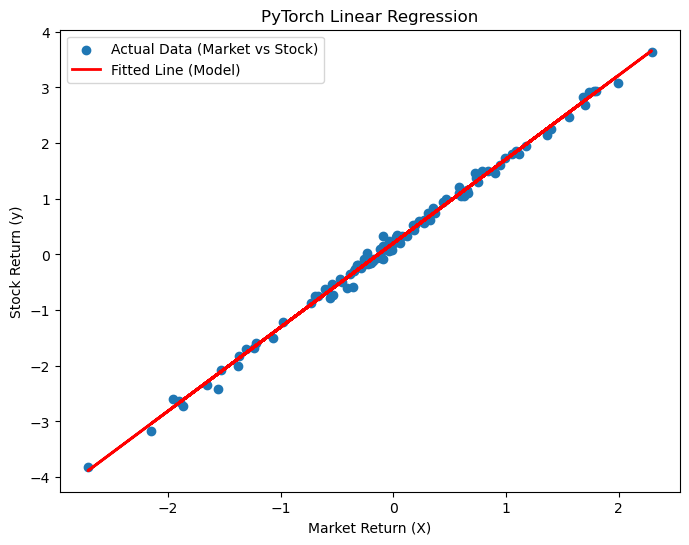


Target Beta: 1.5 | Learned Beta: 1.5071
Target Alpha: 0.2 | Learned Alpha: 0.2030


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERATE SYNTHETIC DATA
# ==========================================
# Let's create some fake data: Market Returns (X) and Stock Returns (y)
# We will assume the "true" Beta (weight) is 1.5, and Alpha (bias) is 0.2

# torch.randn generates random numbers from a standard normal distribution
X = torch.randn(100, 1) # 100 rows, 1 column (Market Returns)
true_beta = 1.5
true_alpha = 0.2

# y = (beta * X) + alpha + some random noise
y = (true_beta * X) + true_alpha + (torch.randn(100, 1) * 0.1) 

# ==========================================
# 2. DEFINE THE PYTORCH MODEL (THE BLUEPRINT)
# ==========================================
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        # nn.Linear is a built-in PyTorch layer. 
        # It automatically creates the 'weight' (beta) and 'bias' (alpha) variables.
        # It takes 1 input feature (Market Return) and outputs 1 prediction (Stock Return).
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        # This defines how the data moves. We just pass the input 'x' 
        # directly through the linear layer we defined in __init__.
        return self.linear_layer(x)

# Create an instance of our blueprint
model = LinearRegressionModel()

# ==========================================
# 3. SETUP LOSS AND OPTIMIZER
# ==========================================
# Mean Squared Error (MSE): Calculates how far our predictions are from the true 'y'
criterion = nn.MSELoss() 

# Stochastic Gradient Descent (SGD): The engine that updates our weights to minimize loss
# lr = learning rate (how big of a step to take during updates)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# ==========================================
# 4. THE TRAINING LOOP (THE "LEARNING" PHASE)
# ==========================================
epochs = 50 # How many times we show the full dataset to the model

print("Starting Training...\n")
for epoch in range(epochs):
    # Step A: Forward pass (make a prediction)
    y_predicted = model(X)
    
    # Step B: Calculate the loss (how wrong was the prediction?)
    loss = criterion(y_predicted, y)
    
    # Step C: Empty the gradients from the last step 
    # (PyTorch accumulates them by default, so we must wipe them clean)
    optimizer.zero_grad()
    
    # Step D: Backpropagation (calculate the gradients/slopes for the weights)
    loss.backward()
    
    # Step E: Update the weights based on the gradients
    optimizer.step()
    
    # Print out progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch+1:2d} | Loss: {loss.item():.4f}")

# ==========================================
# 5. VISUALIZE THE RESULTS
# ==========================================
# We turn off gradient tracking because we are just evaluating/plotting, not training
with torch.no_grad():
    predicted = model(X).detach().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(X.numpy(), y.numpy(), label='Actual Data (Market vs Stock)')
plt.plot(X.numpy(), predicted, color='red', linewidth=2, label='Fitted Line (Model)')
plt.title("PyTorch Linear Regression")
plt.xlabel("Market Return (X)")
plt.ylabel("Stock Return (y)")
plt.legend()
plt.show()

# Let's peek at the final parameters PyTorch learned
print(f"\nTarget Beta: {true_beta} | Learned Beta: {model.linear_layer.weight.item():.4f}")
print(f"Target Alpha: {true_alpha} | Learned Alpha: {model.linear_layer.bias.item():.4f}")